Image loaded successfully
Image shape: (1920, 1080, 3)
Image size: 1080 x 1920


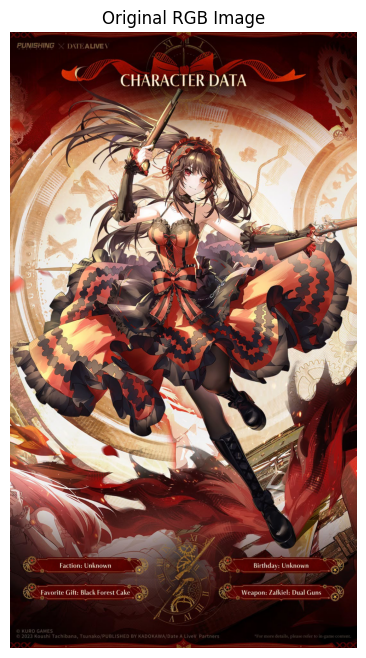

In [9]:
import os
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IMAGE_PATH = "/content/img.jpg"
BLOCK_SIZES = [(4, 4), (8, 8), (16, 16), (32, 32), (64, 64)]
OUTPUT_DIR = "/content/labwork8_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

image_bgr = cv2.imread(IMAGE_PATH)

if image_bgr is None:
    raise ValueError("Could not load image.")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print("Image loaded successfully")
print("Image shape:", image_rgb.shape)
print("Image size:", image_rgb.shape[1], "x", image_rgb.shape[0])

plt.figure(figsize=(6, 8))
plt.imshow(image_rgb)
plt.title("Original RGB Image")
plt.axis("off")
plt.show()

In [10]:
def RGB2HSV(image_rgb, block_size=(16, 16)):
    height, width = image_rgb.shape[:2]
    block_h, block_w = block_size

    H = np.empty((height, width), dtype=np.float32)
    S = np.empty((height, width), dtype=np.float32)
    V = np.empty((height, width), dtype=np.float32)

    for y in range(0, height, block_h):
        for x in range(0, width, block_w):

            y_end = min(y + block_h, height)
            x_end = min(x + block_w, width)

            block = image_rgb[y:y_end, x:x_end]

            R = block[:, :, 0].astype(np.float32) / 255.0
            G = block[:, :, 1].astype(np.float32) / 255.0
            B = block[:, :, 2].astype(np.float32) / 255.0

            max_value = np.maximum(np.maximum(R, G), B)
            min_value = np.minimum(np.minimum(R, G), B)

            delta = max_value - min_value
            hue = np.zeros_like(max_value)
            non_zero_delta = delta != 0

            mask_r = (non_zero_delta & (max_value == R))

            hue[mask_r] = (60.0 * (((G[mask_r] - B[mask_r]) / delta[mask_r]) % 6.0))

            mask_g = (non_zero_delta & (max_value == G) & ~mask_r)

            hue[mask_g] = (60.0 * ((B[mask_g] - R[mask_g]) / delta[mask_g] + 2.0))

            mask_b = (non_zero_delta & (max_value == B) & ~mask_r & ~mask_g)

            hue[mask_b] = (60.0 * ((R[mask_b] - G[mask_b]) / delta[mask_b] + 4.0))

            saturation = np.zeros_like(max_value)

            non_zero_max = max_value != 0

            saturation[non_zero_max] = (delta[non_zero_max] / max_value[non_zero_max])

            value = max_value

            H[y:y_end, x:x_end] = hue
            S[y:y_end, x:x_end] = saturation
            V[y:y_end, x:x_end] = value

    return H, S, V

In [11]:
def HSV2RGB(H, S, V, block_size=(16, 16)):
    height, width = H.shape
    block_h, block_w = block_size

    output = np.empty((height, width, 3), dtype=np.uint8)

    for y in range(0, height, block_h):
        for x in range(0, width, block_w):

            y_end = min(y + block_h, height)
            x_end = min(x + block_w, width)

            h = H[y:y_end, x:x_end]
            s = S[y:y_end, x:x_end]
            v = V[y:y_end, x:x_end]

            d = h / 60.0

            hi = np.floor(d).astype(np.int32) % 6

            f = d - np.floor(d)

            l = v * (1.0 - s)
            m = v * (1.0 - f * s)
            n = v * (1.0 - (1.0 - f) * s)

            r = np.zeros_like(v)
            g = np.zeros_like(v)
            b = np.zeros_like(v)

            mask0 = hi == 0
            r[mask0] = v[mask0]
            g[mask0] = n[mask0]
            b[mask0] = l[mask0]

            mask1 = hi == 1
            r[mask1] = m[mask1]
            g[mask1] = v[mask1]
            b[mask1] = l[mask1]

            mask2 = hi == 2
            r[mask2] = l[mask2]
            g[mask2] = v[mask2]
            b[mask2] = n[mask2]

            mask3 = hi == 3
            r[mask3] = l[mask3]
            g[mask3] = m[mask3]
            b[mask3] = v[mask3]

            mask4 = hi == 4
            r[mask4] = n[mask4]
            g[mask4] = l[mask4]
            b[mask4] = v[mask4]

            mask5 = hi == 5
            r[mask5] = v[mask5]
            g[mask5] = l[mask5]
            b[mask5] = m[mask5]

            rgb_block = np.stack([r * 255.0, g * 255.0, b * 255.0], axis=2)

            output[y:y_end, x:x_end] = np.clip(rgb_block, 0, 255).astype(np.uint8)

    return output

In [12]:
H, S, V = RGB2HSV(image_rgb, block_size=(16, 16))

print("RGB2HSV completed")
print("H range:", float(H.min()), "to", float(H.max()))
print("S range:", float(S.min()), "to", float(S.max()))
print("V range:", float(V.min()), "to", float(V.max()))

reconstructed_rgb = HSV2RGB(H, S, V, block_size=(16, 16))

print("\nHSV2RGB completed")

difference = np.abs(image_rgb.astype(np.int16) - reconstructed_rgb.astype(np.int16))

max_difference = difference.max()
mean_difference = difference.mean()
different_pixels = np.any(difference != 0, axis=2).sum()

total_pixels = image_rgb.shape[0] * image_rgb.shape[1]

print("\nRound-trip comparison:")
print("Maximum absolute difference:", max_difference)
print("Mean absolute difference:", mean_difference)
print("Different pixels:", different_pixels, "/", total_pixels)

if max_difference == 0:
    print("Result: EXACT MATCH")
else:
    print("Result: Small numerical difference exists")

RGB2HSV completed
H range: 0.0 to 359.67742919921875
S range: 0.0 to 1.0
V range: 0.0 to 1.0

HSV2RGB completed

Round-trip comparison:
Maximum absolute difference: 1
Mean absolute difference: 0.17421907150205762
Different pixels: 750185 / 2073600
Result: Small numerical difference exists


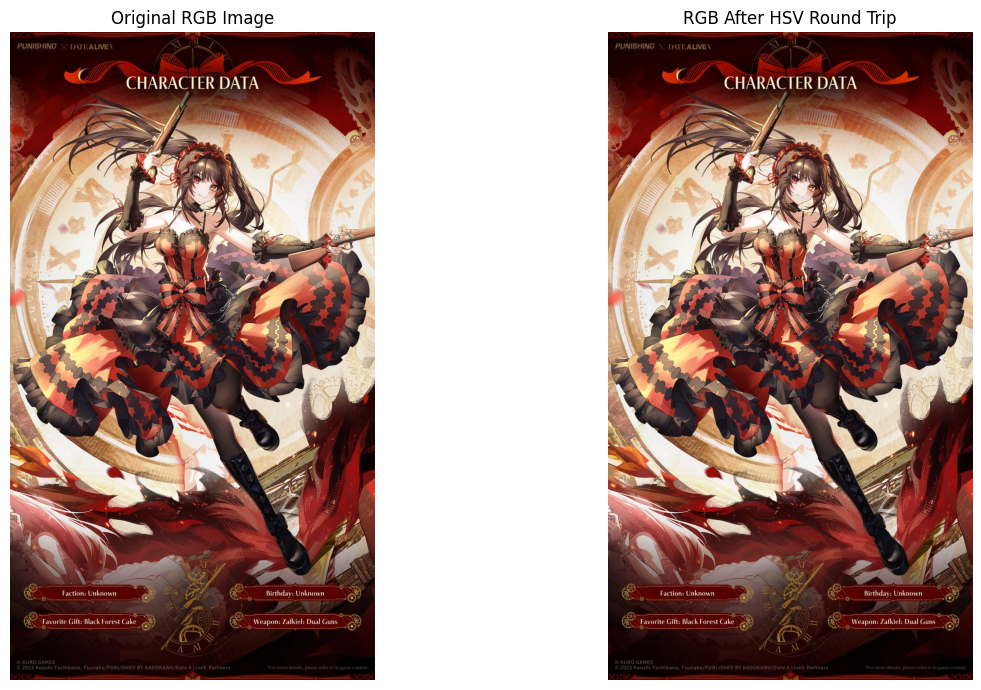

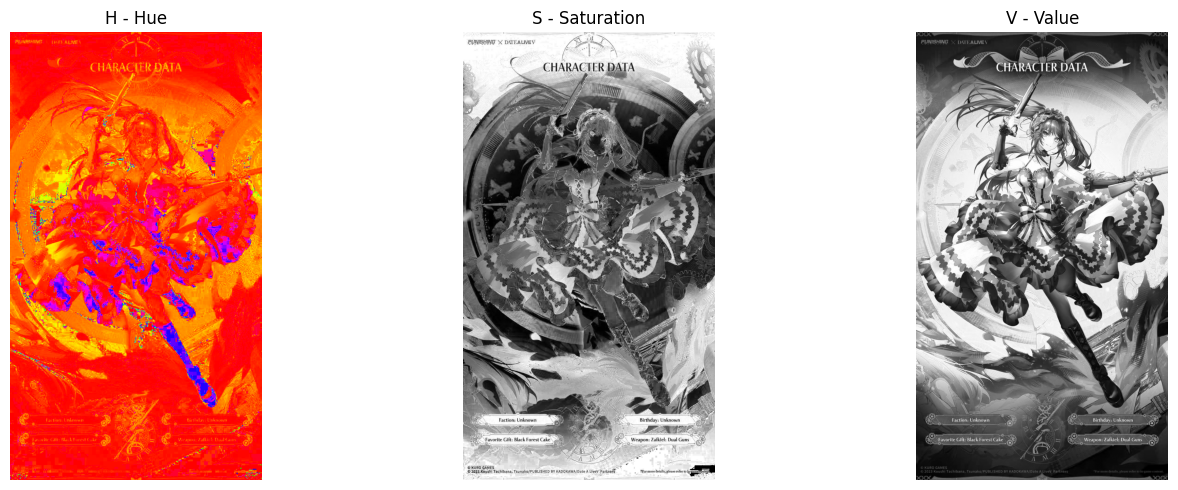

In [13]:
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original RGB Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_rgb)
plt.title("RGB After HSV Round Trip")
plt.axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap="hsv")
plt.title("H - Hue")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("S - Saturation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("V - Value")
plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
benchmark_results = []

for block_size in BLOCK_SIZES:
    print(
        f"Testing block size: "
        f"{block_size[0]} x {block_size[1]}"
    )
    start = time.perf_counter()

    H_test, S_test, V_test = RGB2HSV(image_rgb, block_size)

    rgb2hsv_time = time.perf_counter() - start

    start = time.perf_counter()

    rgb_test = HSV2RGB(H_test, S_test, V_test, block_size)

    hsv2rgb_time = time.perf_counter() - start

    diff = np.abs(image_rgb.astype(np.int16) - rgb_test.astype(np.int16))

    max_diff = int(diff.max())
    mean_diff = float(diff.mean())

    benchmark_results.append({
        "Block Size": (
            f"{block_size[0]} x {block_size[1]}"
        ),
        "RGB2HSV (s)": rgb2hsv_time,
        "HSV2RGB (s)": hsv2rgb_time,
        "Total (s)": rgb2hsv_time + hsv2rgb_time,
        "Max Difference": max_diff,
        "Mean Difference": mean_diff
    })

benchmark_df = pd.DataFrame(benchmark_results)

print("\nBenchmark Results:")
display(benchmark_df)

Testing block size: 4 x 4
Testing block size: 8 x 8
Testing block size: 16 x 16
Testing block size: 32 x 32
Testing block size: 64 x 64

Benchmark Results:


,Block Size,RGB2HSV (s),HSV2RGB (s),Total (s),Max Difference,Mean Difference
0,4 x 4,7.254821,8.450047,15.704868,1,0.174219
1,8 x 8,2.115011,2.094138,4.209148,1,0.174219
2,16 x 16,0.502719,0.616151,1.118870,1,0.174219
3,32 x 32,0.190436,0.269649,0.460084,1,0.174219
4,64 x 64,0.089523,0.145812,0.235335,1,0.174219


In [15]:
print("Correctness verification:")

reference_H, reference_S, reference_V = RGB2HSV(image_rgb, (16, 16))

reference_rgb = HSV2RGB(reference_H, reference_S, reference_V, (16, 16))

for block_size in BLOCK_SIZES:
    H_test, S_test, V_test = RGB2HSV(image_rgb, block_size)

    rgb_test = HSV2RGB(H_test, S_test, V_test, block_size)

    identical = np.array_equal(reference_rgb, rgb_test)

    diff = np.abs(reference_rgb.astype(np.int16) - rgb_test.astype(np.int16))

    print(
        f"{block_size[0]} x {block_size[1]} "
        f"-> identical to 16 x 16: {identical}, "
        f"max difference: {diff.max()}"
    )

Correctness verification:
4 x 4 -> identical to 16 x 16: True, max difference: 0
8 x 8 -> identical to 16 x 16: True, max difference: 0
16 x 16 -> identical to 16 x 16: True, max difference: 0
32 x 32 -> identical to 16 x 16: True, max difference: 0
64 x 64 -> identical to 16 x 16: True, max difference: 0


In [16]:
cv2.imwrite(os.path.join(OUTPUT_DIR, "original.png"), cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR))

cv2.imwrite(os.path.join(OUTPUT_DIR, "reconstructed_rgb.png"), cv2.cvtColor(reconstructed_rgb, cv2.COLOR_RGB2BGR))

np.save(os.path.join(OUTPUT_DIR, "H.npy"), H)
np.save(os.path.join(OUTPUT_DIR, "S.npy"), S)
np.save(os.path.join(OUTPUT_DIR, "V.npy"), V)

benchmark_df.to_csv(os.path.join(OUTPUT_DIR, "benchmark.csv"), index=False)

print("\nSaved files:")

for filename in sorted(os.listdir(OUTPUT_DIR)):
    print("-", filename)


Saved files:
- H.npy
- S.npy
- V.npy
- benchmark.csv
- original.png
- reconstructed_rgb.png
